# Table of Contents 
* [Notebook](#notebook-setup)
* [Time-Series Cross-Validation Split](#tscv)
* [Classical Models](#classical-models)
    * [Linear Regression](#linear-regression)
    * [Time-Series Methods](#time-series-methods)
        * [Baseline ARIMA](#arima)
        * [Seasonal ARIMA](#sarima)
    * [XGBoost Regressor](#xgb)
        * [Baseline XGBoost](#xgb-baseline)
        * [Randomized Search CV](#xgb-randomized)
        * [Grid Search CV](#xgb-grid)
        * [Tuned XGBoost](#xgb-tuned)
        * [Feature Importance](#xgb-feature-importance)

# Notebook Setup <a class="anchor" id="notebook-setup"></a>

In [1]:
pip install xgboost


[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: /Users/rg/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pmdarima


[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: /Users/rg/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import sklearn 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
import itertools
from pmdarima import auto_arima
import xgboost as xgb
from scipy.stats import randint as sp_randint
from scipy.stats import uniform
import pickle

In [4]:
#Defining RMSE as a function
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

#Creating a metric that negates the RMSE 
rmse_scorer = make_scorer(rmse, greater_is_better=False)

In [5]:
X_train = pd.read_csv('/Users/rg/anaconda3/MSIN0097 - Predictive Analytics/X_train.csv')
y_train = pd.read_csv('/Users/rg/anaconda3/MSIN0097 - Predictive Analytics/y_train.csv')
X_test = pd.read_csv('/Users/rg/anaconda3/MSIN0097 - Predictive Analytics/X_test.csv')
y_test = pd.read_csv('/Users/rg/anaconda3/MSIN0097 - Predictive Analytics/y_test.csv')

In [6]:
X_train.info() #code to check

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6041 entries, 0 to 6040
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Timestamp                                6041 non-null   int64  
 1   RSI                                      6041 non-null   float64
 2   High_index_log_scaled                    6041 non-null   float64
 3   Low_index_log_scaled                     6041 non-null   float64
 4   Close_index_log_scaled                   6041 non-null   float64
 5   Adj_Close_index_log_scaled               6041 non-null   float64
 6   Volume_tbills_log_scaled                 6041 non-null   float64
 7   High-Close_log_scaled                    6041 non-null   float64
 8   GDP per capita_log_scaled                6041 non-null   float64
 9   Open_index_t-1_log_scaled                6041 non-null   float64
 10  Open_index_t-2_log_scaled                6041 no

In [7]:
y_train.info() #code to check

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6041 entries, 0 to 6040
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       6041 non-null   float64
dtypes: float64(1)
memory usage: 47.3 KB


# Time-Series Cross-Validation Split <a class="anchor" id="tscv"></a>

Before we begin our modelling, we will split our training set into training and validation using time-series cross validation split.

In [8]:
# Initialize TimeSeriesSplit with 5 splits
tscv = TimeSeriesSplit(n_splits=5) #initialising 5 folds for cross-validation

# Applying TimeSeriesSplit to our training data
for train_index, test_index in tscv.split(X_train):
    X_train_rest, X_val = X_train.iloc[train_index], X_train.iloc[test_index]

for train_index, test_index in tscv.split(y_train): 
    y_train_rest, y_val = y_train.iloc[train_index], y_train.iloc[test_index]

In [9]:
X_train_rest.info() #code to check

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5035 entries, 0 to 5034
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Timestamp                                5035 non-null   int64  
 1   RSI                                      5035 non-null   float64
 2   High_index_log_scaled                    5035 non-null   float64
 3   Low_index_log_scaled                     5035 non-null   float64
 4   Close_index_log_scaled                   5035 non-null   float64
 5   Adj_Close_index_log_scaled               5035 non-null   float64
 6   Volume_tbills_log_scaled                 5035 non-null   float64
 7   High-Close_log_scaled                    5035 non-null   float64
 8   GDP per capita_log_scaled                5035 non-null   float64
 9   Open_index_t-1_log_scaled                5035 non-null   float64
 10  Open_index_t-2_log_scaled                5035 no

In [10]:
y_train_rest.info() #code to check

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5035 entries, 0 to 5034
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       5035 non-null   float64
dtypes: float64(1)
memory usage: 78.7 KB


# Classical Models <a class="anchor" id="classical-models"></a>

Now that our training and validation split has been made, we can start to evaluate different models. 

## Linear Regression <a class="anchor" id="linear-regression"></a>

In [11]:
#Fitting the Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train_rest, y_train_rest) #fitting the training data

LinearRegression()

In [12]:
# Predicting the target values for the training set
y_train_rest_lin_reg_pred = lin_reg.predict(X_train_rest)

Before evaluating the RMSE for different subsets, we need to load the scaler used for original transformations

We will define a function for transforming the scaled RMSEs back to their original scale

In [13]:
# Evaluating in-sample model performance using RMSE

# Calculating and printing the Mean Squared Error
train_lin_reg_rmse = mean_squared_error(y_train_rest, y_train_rest_lin_reg_pred, squared=False)
print(f"In-sample RMSE: {train_lin_reg_rmse:.3f}")

In-sample RMSE: 0.009


In [14]:
#Predicting the target values for the validation
y_val_lin_reg_pred = lin_reg.predict(X_val)

# Calculating and printing the Mean Squared Error
val_lin_reg_rmse = mean_squared_error(y_val, y_val_lin_reg_pred, squared=False)
print(f"Validation RMSE: {val_lin_reg_rmse:.3f}")

Validation RMSE: 0.007


In [15]:
#Predicting the target values for the test set
y_test_lin_reg_pred = lin_reg.predict(X_test)

# Calculating and printing the Mean Squared Error
test_lin_reg_rmse = mean_squared_error(y_test, y_test_lin_reg_pred, squared=False)
print(f"Test RMSE: {test_lin_reg_rmse:.3f}")

Test RMSE: 0.049


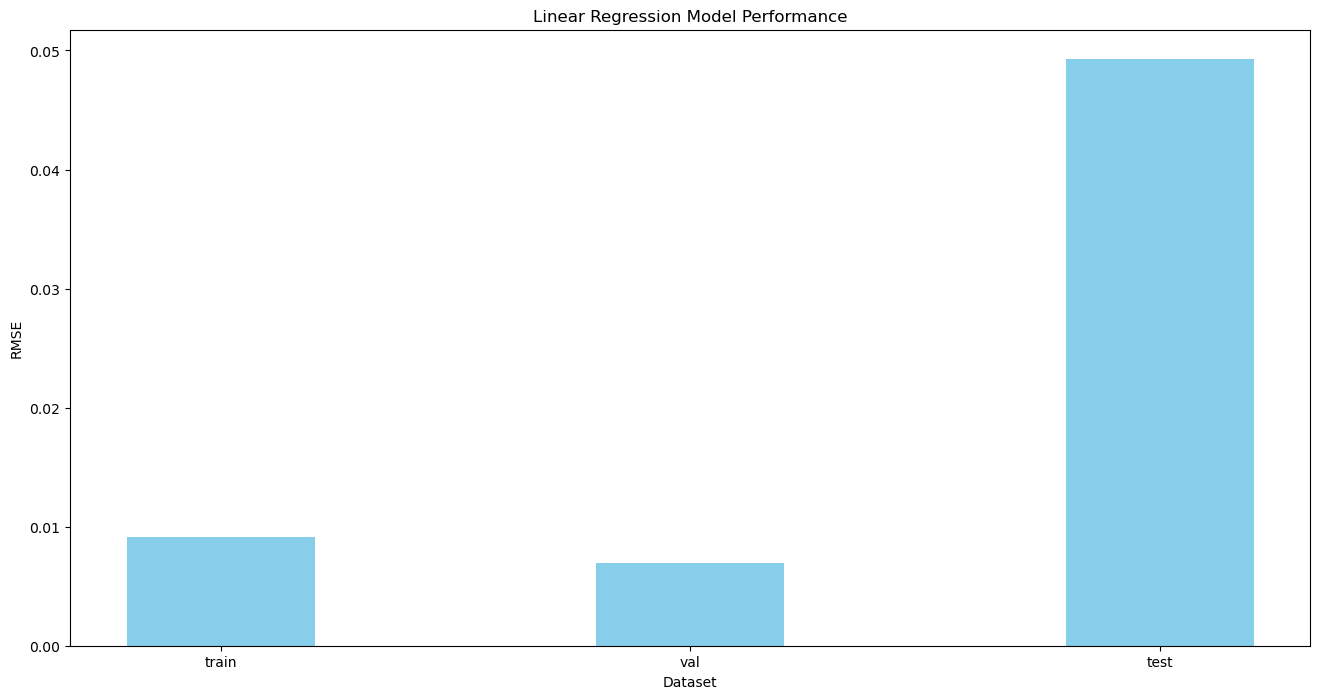

In [16]:
# Mean Squared Error values for each dataset
mse_values = {'train': train_lin_reg_rmse, 'val': val_lin_reg_rmse, 'test': test_lin_reg_rmse}

# Extracting labels and corresponding values
labels = list(mse_values.keys())
values = list(mse_values.values())

# Create a bar plot
plt.figure(figsize=(16, 8))
bars = plt.bar(labels, values, width=0.4, color='skyblue')


# Adding titles and labels
plt.title('Linear Regression Model Performance')
plt.xlabel('Dataset')
plt.ylabel('RMSE')

# Display the plot
plt.show()


In [78]:
#Checking the coefficients of the linear regression 

coefficients = lin_reg.coef_
intercept = lin_reg.intercept_

#Creating a dataframe with the coefficients
coefficients_df = pd.DataFrame(data=coefficients.reshape(-1,1),    # Coefficients from the model
                        index=X_train_rest.columns,  # Column names from existing_df as index
                        columns=['Coefficient'])  # Name the column in the DataFrame

coefficients_df['Abs value'] = coefficients_df['Coefficient'].abs() #calculating absolute value of coefficients

coefficients_df.sort_values(by='Abs value', ascending=False) #sorting the df from highest to lowest absolute value

,Coefficient,Abs value
High_index_log_scaled,8.474317e-01,8.474317e-01
Low_index_log_scaled,6.523283e-01,6.523283e-01
Adj_Close_index_log_scaled,-2.812352e-01,2.812352e-01
Close_index_log_scaled,-2.812352e-01,2.812352e-01
GDP per capita_log_scaled,7.455715e-02,7.455715e-02
Open_index_t-1_log_scaled,4.094221e-02,4.094221e-02
Open_index_t-2_log_scaled,-2.440662e-02,2.440662e-02
Open_index_t-7_log_scaled,-2.275663e-02,2.275663e-02
Open_index_t-3_log_scaled,1.783997e-02,1.783997e-02
Open_index_t-4_log_scaled,-1.603911e-02,1.603911e-02


The linear regression model seems to perform quite well on the test and serves as a good benchmark for other models. We also observe 

For this reason we shall look to explore more complex models starting with ARIMA.  

## Time-Series Methods <a class="anchor" id="time-series-methods"></a>

Before applying time-series methods, we shall do a stationarity check visually and statistically on our target variable and features. 

In [17]:
#Calculating the roll mean over time 
window_size = 200  # You can adjust this size based on your data
moving_average = y_train_rest['0'].rolling(window=window_size).mean()

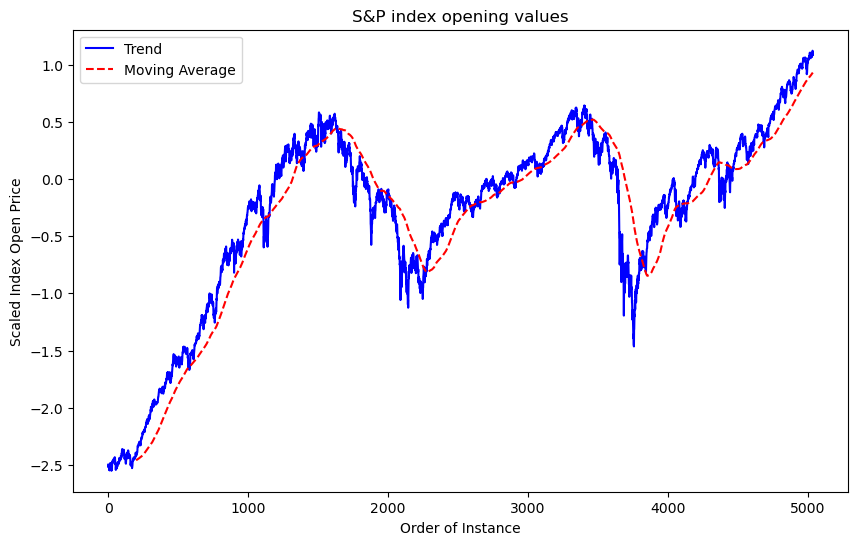

In [18]:
#Checking trend of y_train over time 

plt.figure(figsize=(10, 6))
plt.plot(y_train_rest.index, y_train_rest.values, label='Trend', color='blue')

# Plotting the moving average
plt.plot(y_train_rest.index, moving_average, label='Moving Average', color='red', linestyle='--')

plt.title('S&P index opening values')
plt.xlabel('Order of Instance')
plt.ylabel('Scaled Index Open Price')
plt.legend()
plt.show()


We observe that the rolling mean is changing over time which suggests non-stationarity.

In [19]:
#Applying the Augmented Dickey-Fuller Test 


# Checking degree of stationarity of data
result = adfuller(y_train_rest)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.1445916051182974
p-value: 0.22696602261057897


A Dickey-Fuller p-value above 5% confirms the non-stationarity observed in the data. 

In [20]:
#Copying train, validation and test sets before data augmentation
y_train_arima = y_train_rest.copy()
y_val_arima = y_val.copy()
y_test_arima = y_test.copy()

In [21]:
#Differencing the target variable

In [22]:
y_train_arima.head()

,0
0,-2.497612
1,-2.518777
2,-2.503545
3,-2.515904
4,-2.523630


In [23]:
y_train_arima.rename(columns={'0':'Open_price'}, inplace=True)

In [24]:
y_train_arima['first_diff'] = y_train_arima['Open_price'].diff()

In [25]:
y_train_arima.head() 

,Open_price,first_diff
0,-2.497612,NaN
1,-2.518777,-0.021166
2,-2.503545,0.015232
3,-2.515904,-0.012359
4,-2.523630,-0.007727


The differencing creates a NaN value in the first row

In [26]:
y_train_arima.fillna(0, inplace=True) #filling missing NaN

In [27]:
y_train_rest.head() #code to check

,0
0,-2.497612
1,-2.518777
2,-2.503545
3,-2.515904
4,-2.523630


Now with this differenced data, we shall build the ARIMA model.

### Baseline ARIMA  <a class="anchor" id="arima"></a>

In order to identify the parameters, p and q for the model, we shall plot the autocorrelation and partial autocorrelation factor plots. 

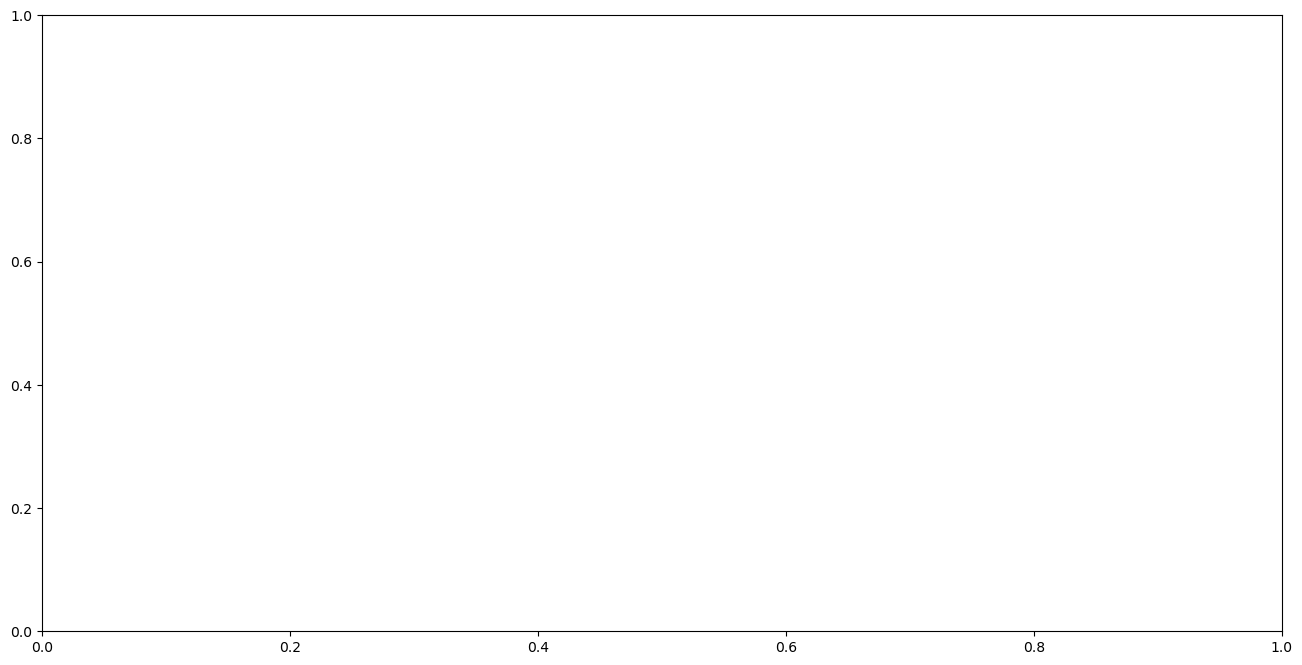

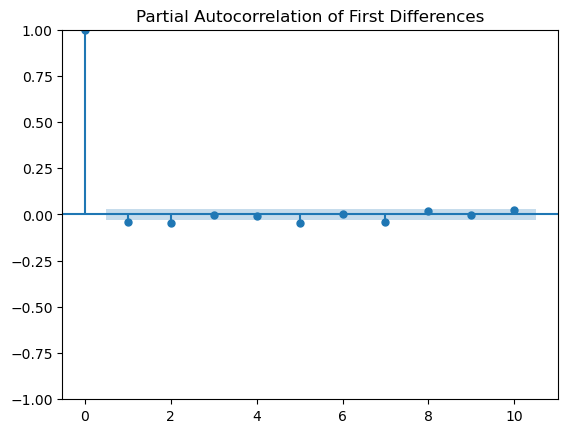

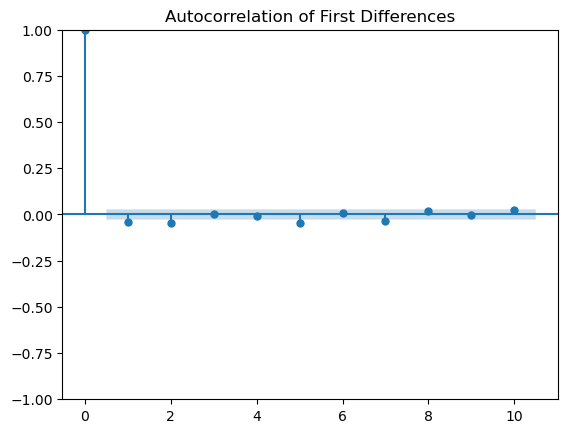

In [28]:
fig, ax = plt.subplots(figsize=(16, 8))  
plot_pacf(y_train_arima['first_diff'], lags=10, alpha=0.05, title='Partial Autocorrelation of First Differences')
plot_acf(y_train_arima['first_diff'], lags=10, alpha=0.05, title='Autocorrelation of First Differences')
plt.show()

##kindly ignore blank visualisation 

In the PACF and ACF graphs, we are looking for the lag periods at which the autocorrelation factor extends beyond the highlighted insignificance zone

The PACF determines the value of p while the ACF determines the value of q. 

We observe that after the first lag both the partial autocorrelation and autocorrelation factors are significant

In [29]:
y_train_arima

,Open_price,first_diff
0,-2.497612,0.000000
1,-2.518777,-0.021166
2,-2.503545,0.015232
3,-2.515904,-0.012359
4,-2.523630,-0.007727
...,...,...
5030,1.097223,0.020021
5031,1.114211,0.016988
5032,1.120654,0.006443
5033,1.119078,-0.001576


In [30]:
#Defining the ARIMA model
p, d, q = 1, 1, 1  # Defining AR, MA and differencing parameters
arima_model = ARIMA(y_train_arima['Open_price'], 
                order=(p, d, q))

#Fitting the ARIMA model
arima_results = arima_model.fit()


#Predicting the future values
prediction = arima_results.predict(start=y_val.index[0], end=y_val.index[-1])

#Adding forecast to validation set 
y_val_arima['ARIMA_values'] = prediction

In [31]:
y_val_arima.head()

,0,ARIMA_values
5035,1.058553,1.084647
5036,1.068331,1.085314
5037,1.094958,1.085764
5038,1.038180,1.086068
5039,1.020922,1.086272


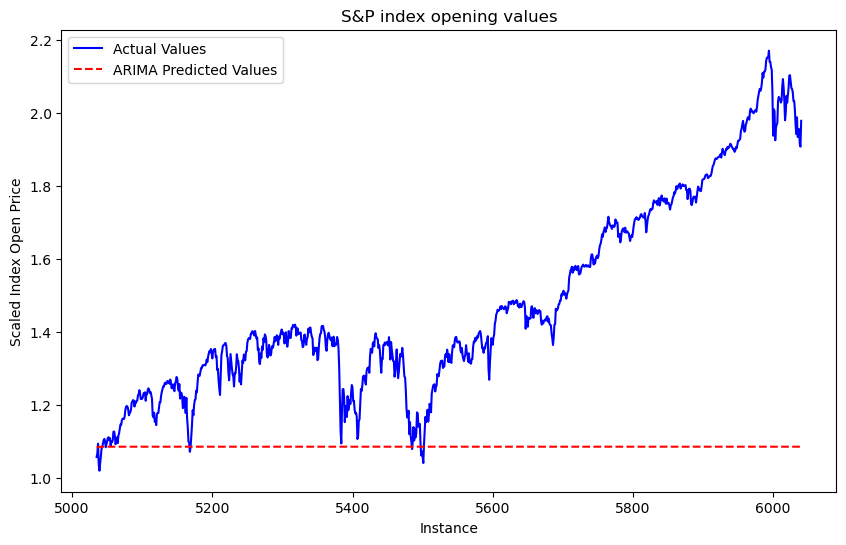

In [32]:
#Checking forecast accuracy 

plt.figure(figsize=(10, 6))
plt.plot(y_val_arima['0'], label='Actual Values', color='blue')

#Plotting the ARIMA-generated values
plt.plot(y_val_arima['ARIMA_values'], label='ARIMA Predicted Values', color='red', linestyle='--')

plt.title('S&P index opening values')
plt.xlabel('Instance')
plt.ylabel('Scaled Index Open Price')
plt.legend()
plt.show()

In [33]:
#Calculating the RMSE of the baseline ARIMA 

ARIMA_val_rmse = np.sqrt(mean_squared_error(y_val_arima['0'], prediction))
ARIMA_val_rmse

0.47414654183743526

We observe from the visual representation above and the performance metric that the baseline ARIMA does not fit new data well. Therefore, the trend in the data may be observed over longer lag periods, which may also be recurring and so we shall investigate further iterations of the ARIMA model.

### Seasonal ARIMA  <a class="anchor" id="sarima"></a>

Before fitting the model, let us decompose the trend we saw initially into the different seasonal components

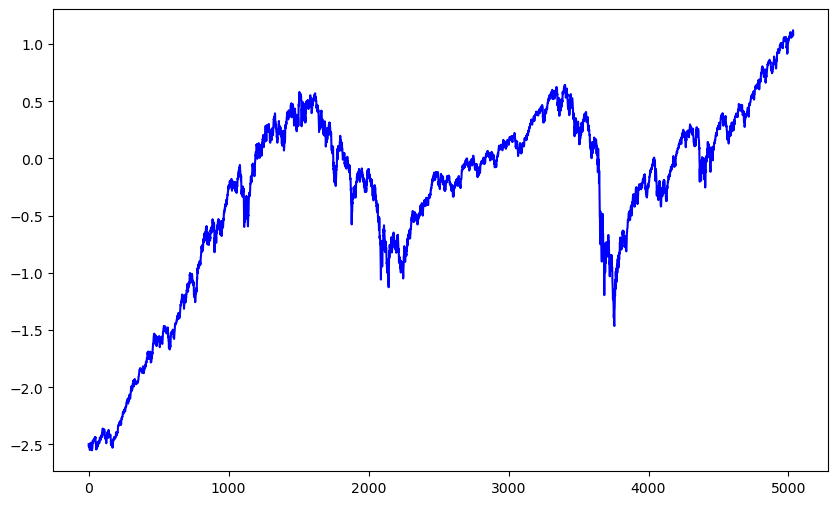

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(y_train_arima['Open_price'], label='Trend', color='blue')

plt.show()

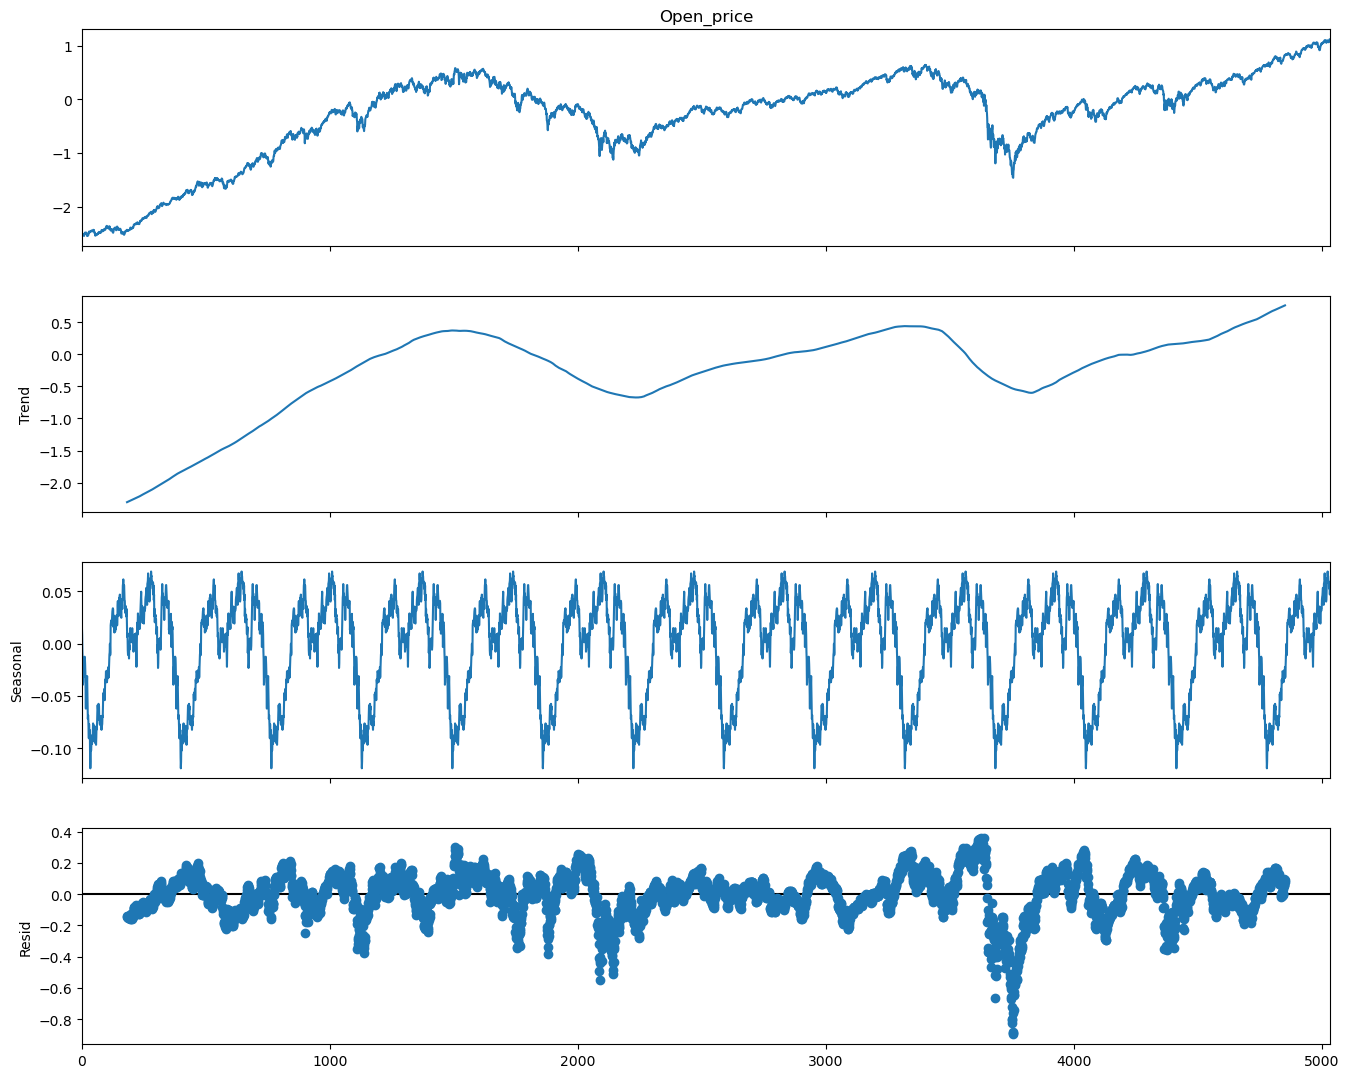

In [35]:
# Decompose the time series
decomposition = seasonal_decompose(y_train_arima['Open_price'], model='additive', period=365) #assuming yearly seasonality over measurement period

#Plotting the decomposed components
fig = decomposition.plot()
fig.set_size_inches(15, 12)
plt.show()


What we observe is an obvious seasonal pattern with clear peaks and troughs at periodic intervals. This makes a case for the use of the SARIMA model. 

As we did in the case of ARIMA, we shall create a differenced variable but this time the period of differencing will be increased as we will consider seasonal differencing. 

In [36]:
y_train_arima['seasonal_diff']= y_train_arima['Open_price'].diff(periods=15) #we assume bi-weekly seasonality 

In [37]:
y_train_arima.fillna(0,inplace=True) #filling NaN values created by differencing 

Now we move to identifying possible parameter values for the SARIMA model. We will revert to the PACF and ACF plots here. 

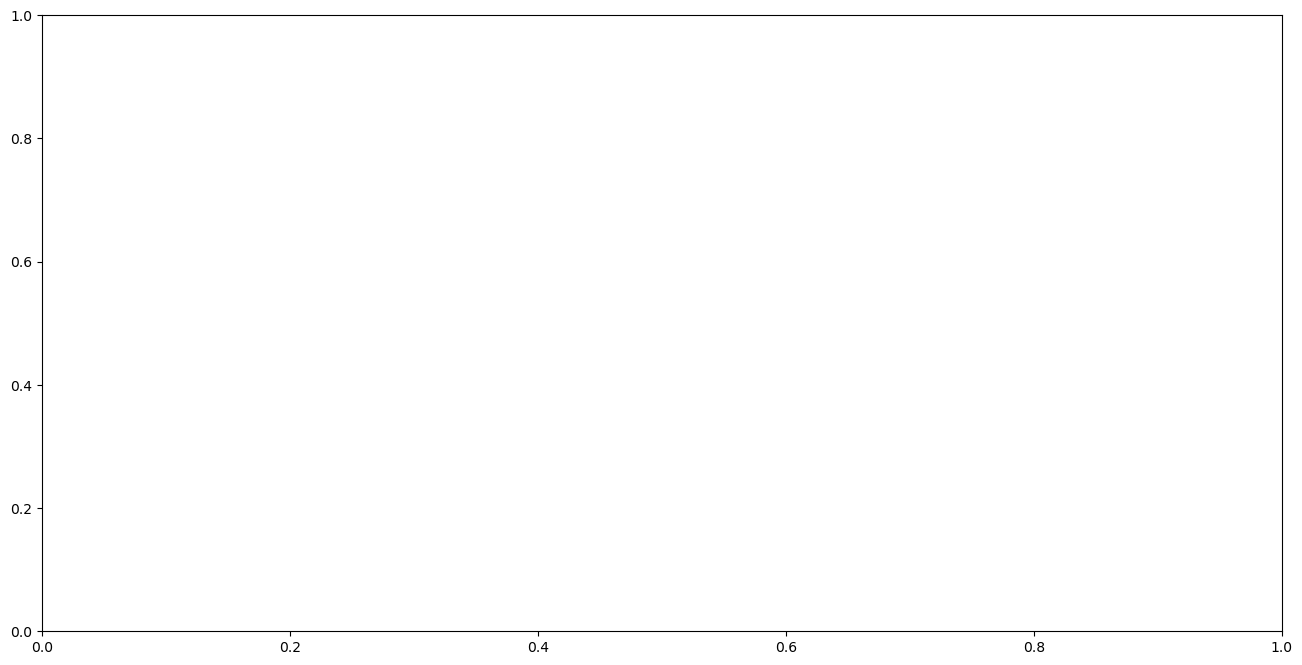

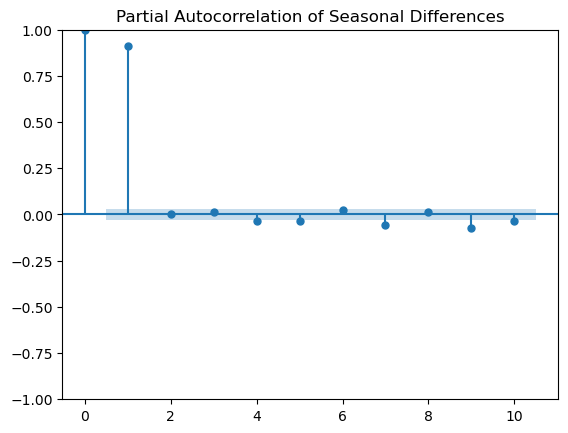

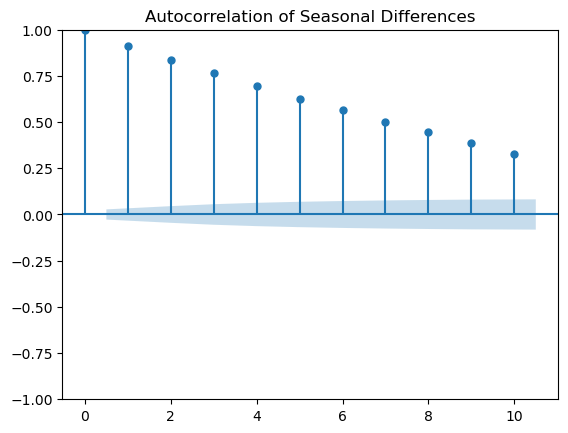

In [38]:
fig, ax = plt.subplots(figsize=(16, 8))  
plot_pacf(y_train_arima['seasonal_diff'], lags=10, alpha=0.05, title='Partial Autocorrelation of Seasonal Differences')
plot_acf(y_train_arima['seasonal_diff'], lags=10, alpha=0.05, title='Autocorrelation of Seasonal Differences')
plt.show()

##kindly ignore blank visualisation 

As mentioned previously, PACF determines the value of p while the ACF determines the value of q. We see that with our seasonal difference values, there is a high degree of autocorrelation and also some degree of partial autocorrelation. 

In [39]:
#Using auto arima to grid search the best params
sarima_model = auto_arima(y_train_arima['Open_price'],
                      start_p=1, start_q=1, max_p=2, max_q=10,
                      start_P=1, start_Q=1, max_P=2, max_Q=10,
                      d=None, D=1,  
                      seasonal=True,
                      m=7,  
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)

print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[7] intercept   : AIC=inf, Time=6.90 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=-12127.885, Time=0.25 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=-19140.084, Time=3.08 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=-15547.336, Time=2.67 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=-12105.698, Time=0.23 sec
 ARIMA(1,0,0)(0,1,0)[7] intercept   : AIC=-17818.436, Time=0.33 sec
 ARIMA(1,0,0)(2,1,0)[7] intercept   : AIC=-19622.176, Time=6.79 sec
 ARIMA(1,0,0)(2,1,1)[7] intercept   : AIC=inf, Time=12.35 sec
 ARIMA(1,0,0)(1,1,1)[7] intercept   : AIC=inf, Time=8.86 sec
 ARIMA(0,0,0)(2,1,0)[7] intercept   : AIC=-12142.239, Time=2.36 sec
 ARIMA(2,0,0)(2,1,0)[7] intercept   : AIC=-19620.182, Time=13.17 sec
 ARIMA(1,0,1)(2,1,0)[7] intercept   : AIC=-19620.182, Time=9.23 sec
 ARIMA(0,0,1)(2,1,0)[7] intercept   : AIC=-15553.795, Time=5.76 sec
 ARIMA(2,0,1)(2,1,0)[7] intercept   : AIC=-19618.403, Time=15.81 sec
 ARIMA(1,0,0)(2,1,0)[7]

In [40]:
#Evaluating SARIMA model with auto-ARIMA best params

#Fitting the SARIMA Model again
best_param_sarima = SARIMAX(y_train_arima['Open_price'], order=(1,0,0),seasonal_order=(2,1,0,7),  
                enforce_stationarity=False, enforce_invertibility=False, 
                )

best_param_sarima_results = best_param_sarima.fit()


#Predicting the future values
sarima_prediction = best_param_sarima_results.predict(start=y_val_arima.index[0], end=y_val_arima.index[-1])

#Adding predictions to validation set 
y_val_arima['SARIMA_values'] = sarima_prediction


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.78674D+00    |proj g|=  1.08257D+00


 This problem is unconstrained.



At iterate    5    f= -1.79615D+00    |proj g|=  3.92245D+00

At iterate   10    f= -1.89507D+00    |proj g|=  3.69890D-01

At iterate   15    f= -1.90043D+00    |proj g|=  2.89375D+00

At iterate   20    f= -1.93037D+00    |proj g|=  2.81918D-01

At iterate   25    f= -1.94277D+00    |proj g|=  1.42781D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4     27     33      1     0     0   2.679D-03  -1.943D+00
  F =  -1.9427797561401421     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


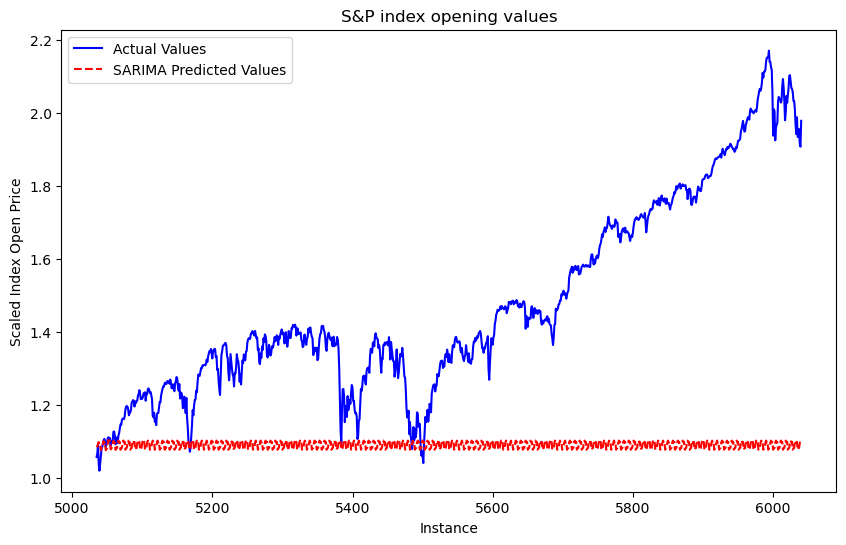

In [41]:
#Checking predictive accuracy 

plt.figure(figsize=(10, 6))
plt.plot(y_val_arima['0'], label='Actual Values', color='blue')

#Plotting the moving average
plt.plot(y_val_arima['SARIMA_values'], label='SARIMA Predicted Values', color='red', linestyle='--')

plt.title('S&P index opening values')
plt.xlabel('Instance')
plt.ylabel('Scaled Index Open Price')
plt.legend()
plt.show()

In [42]:
#Evaluating SARIMA model with a degree of seasonal differencing and the original non-seasonal parameters with periodicty 

#Fitting the SARIMA Model again
sarima_tuned = SARIMAX(y_train_arima['Open_price'], order=(1,1,1),seasonal_order=(1,1,1,7),  
                enforce_stationarity=False, enforce_invertibility=False, 
                )

sarima_tuned_results = sarima_tuned.fit()


#Predicting values in validation set
sarima_tuned_prediction = sarima_tuned_results.predict(start=y_val_arima.index[0], end=y_val_arima.index[-1])

#Adding predictions to validation set 
y_val_arima['SARIMA_values_2'] = sarima_tuned_prediction


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.93760D+00    |proj g|=  1.00573D+01


 This problem is unconstrained.



At iterate    5    f= -2.00691D+00    |proj g|=  1.95542D+00

At iterate   10    f= -2.06915D+00    |proj g|=  5.39232D+00

At iterate   15    f= -2.07500D+00    |proj g|=  1.08829D-01

At iterate   20    f= -2.07794D+00    |proj g|=  8.45069D-01

At iterate   25    f= -2.08118D+00    |proj g|=  3.53389D-02

At iterate   30    f= -2.08128D+00    |proj g|=  2.08801D-02

At iterate   35    f= -2.08129D+00    |proj g|=  1.14807D-02

At iterate   40    f= -2.08135D+00    |proj g|=  1.23299D-01

At iterate   45    f= -2.08150D+00    |proj g|=  4.39600D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     46     67   

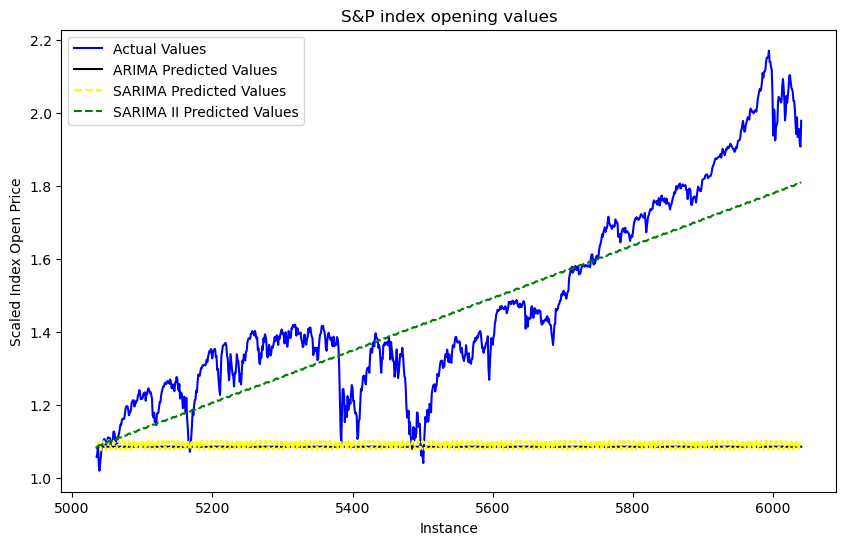

In [43]:
#Checking predictive accuracy 

plt.figure(figsize=(10, 6))
plt.plot(y_val_arima['0'], label='Actual Values', color='blue')

#Plotting the baseline ARIMA 
plt.plot(y_val_arima['ARIMA_values'], label='ARIMA Predicted Values', color='black', linestyle='-')


#Plotting the auto-ARIMA generated SARIMA
plt.plot(y_val_arima['SARIMA_values'], label='SARIMA Predicted Values', color='yellow', linestyle='--')

#Plotting the tuned SARIMA 
plt.plot(y_val_arima['SARIMA_values_2'], label='SARIMA II Predicted Values', color='green', linestyle='--')

plt.title('S&P index opening values')
plt.xlabel('Instance')
plt.ylabel('Scaled Index Open Price')
plt.legend()
plt.show()

In [44]:
#Evaluating performance of SARIMA II on test set 
sarima_test_prediction = sarima_tuned_results.predict(start=y_test_arima.index[0], end=y_test_arima.index[-1])

#Adding prediction to test set 
y_test_arima['SARIMA_values'] = sarima_test_prediction

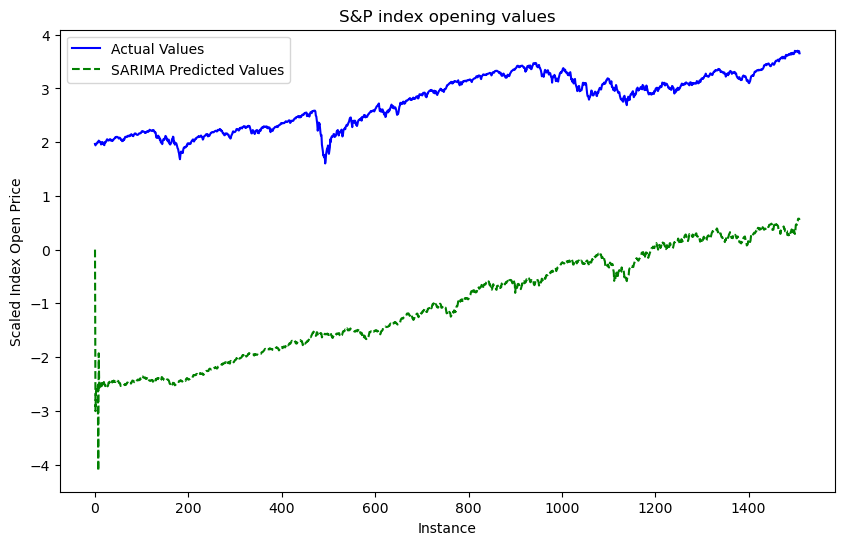

In [45]:
#Plotting SARIMA prediction on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_arima['0'], label='Actual Values', color='blue')
#Plotting the tuned SARIMA 
plt.plot(y_test_arima['SARIMA_values'], label='SARIMA Predicted Values', color='green', linestyle='--')

plt.title('S&P index opening values')
plt.xlabel('Instance')
plt.ylabel('Scaled Index Open Price')
plt.legend()
plt.show()

In [46]:
#Calculating the test RMSE of SARIMA after tuning

SARIMA_test_rmse = np.sqrt(mean_squared_error(y_test_arima['0'], sarima_test_prediction))
SARIMA_test_rmse

3.827749753249256

From the SARIMA we get a better understanding of the trend in the target variable and see that the model captures the seasonal trends well even for the test data. However, we are still unable to predict the values themselves well. 

To further our analysis, we will look at Boosting and attempt to use XGboost regressor.

## XGBoost Regressor <a class="anchor" id="xgb"></a>

### Baseline XGBoost  <a class="anchor" id="xgb-baseline"></a>

In [47]:
#Defining XGBoost regressor instance with hyperparameters and assigning to new variable
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', colsample_bytree=0.5, learning_rate=0.1,
                          max_depth=3, n_estimators=10, random_state=123) 

#Fitting the model on the whole training set
xg_reg.fit(X_train_rest, y_train_rest)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=10, n_jobs=None,
             num_parallel_tree=None, random_state=123, ...)

In [48]:
#Evaluating the baseline model on the training set 

#Predicting values using training set
y_train_XG_boost_pred = xg_reg.predict(X_train_rest)

# #Evaluating the model on the validation data
train_XGboost_rmse = np.sqrt(mean_squared_error(y_train_rest, y_train_XG_boost_pred))
print(f"Train RMSE: {train_XGboost_rmse:.2f}")

Train RMSE: 0.29


In [49]:
#Evaluating the baseline model on the validation set 

#Predicting values using validation set
y_val_XG_boost_pred = xg_reg.predict(X_val)

# #Evaluating the model on the validation data
val_XGboost_rmse = np.sqrt(mean_squared_error(y_val, y_val_XG_boost_pred))
print(f"Val RMSE: {val_XGboost_rmse:.2f}")

Val RMSE: 1.05


In [50]:
#Evaluating the baseline model on the test set 

#Predicting values using test data
y_test_XG_boost_pred = xg_reg.predict(X_test)

# #Evaluating the model on the validation data
test_XGboost_rmse = np.sqrt(mean_squared_error(y_test, y_test_XG_boost_pred))
print(f"Test RMSE: {test_XGboost_rmse:.2f}")

Test RMSE: 2.35


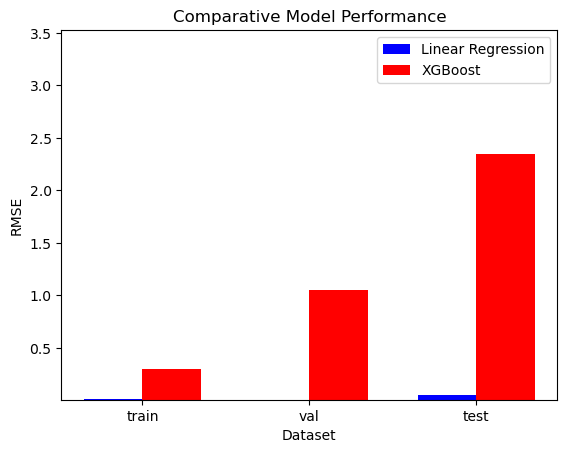

In [51]:
mse_values = {'train': train_lin_reg_rmse, 'val': val_lin_reg_rmse, 'test': test_lin_reg_rmse}
xgboost_mse_values = {'train': train_XGboost_rmse, 'val': val_XGboost_rmse, 'test': test_XGboost_rmse}

labels = list(mse_values.keys())
lin_reg_rmse = list(mse_values.values())
xgboost_rmse = list(xgboost_mse_values.values())

# Number of groups and bar width
num_groups = len(labels)
bar_width = 0.35

# Create indices for each set of bars
index = np.arange(num_groups)

# Plotting the bars for Linear Regression and XGBoost
plt.bar(index, lin_reg_rmse, bar_width, label='Linear Regression', color='blue')
plt.bar(index + bar_width, xgboost_rmse, bar_width, label='XGBoost', color='red')

#Adjusting zoom 
min_rmse = min(min(lin_reg_rmse), min(xgboost_rmse))
max_rmse = max(max(lin_reg_rmse), max(xgboost_rmse))
plt.ylim(min_rmse * 0.90, max_rmse * 1.5) 


plt.xlabel('Dataset')
plt.ylabel('RMSE')
plt.title('Comparative Model Performance')
plt.xticks(index + bar_width / 2, labels)
plt.legend()
plt.show()

While the baseline XGboost performs than time-series methods such as SARIMA, the comparison with the simple linear regression model suggests that its performance can be significantly improved. 

### Randomized Search CV  <a class="anchor" id="xgb-randomized"></a>

In [52]:
#Defining the model 
XGBRT = xgb.XGBRegressor(objective='reg:squarederror')

#Defining the parameter grid to search
param_dist = {
    'n_estimators': sp_randint(10, 50),
    'max_depth': sp_randint(3, 10),
    'learning_rate': uniform(0.01, 0.2), 
    'subsample': uniform(0.6, 0.4),  
    'colsample_bytree': uniform(0.5, 0.5)  
}


#Setting up RandomizedSearchCV
randomized_search = RandomizedSearchCV(XGBRT, param_distributions=param_dist,
                                   n_iter=50, cv=tscv, scoring=rmse_scorer, verbose=1, 
                                       random_state=123, n_jobs=-1)

#Fitting RandomizedSearchCV
randomized_search.fit(X_train_rest, y_train_rest)

#Checking best model result
print("Best parameters found: ", randomized_search.best_params_)
print("Best cross-validation RMSE: {:.2f}".format(-randomized_search.best_score_))



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:  {'colsample_bytree': 0.8453691142364739, 'learning_rate': 0.17656730626422126, 'max_depth': 6, 'n_estimators': 48, 'subsample': 0.8694639943384548}
Best cross-validation RMSE: 0.20


We observe that the baseline XGboost regressor performed better than the observed result for Randomized Search on the validation set. As an alternative to random search, we will attempt to identify the best parameters through Grid Search. 

### Grid Search CV <a class="anchor" id="xgb-grid"></a>

In [53]:
#Listing fixed params 
learning_rate=0.1
min_child_weight=1
subsample=0.8,
colsample_bytree=0.8
colsample_bylevel=0.8
gamma=0
objective='reg:squarederror' 

#Defining the parameter grid for n_estimators and max_depth
param_grid = {
    'n_estimators': range(50, 201, 50),
    'max_depth': range(3, 10)
}

#Setting up the GridSearchCV object
grid_search = GridSearchCV(estimator=xg_reg, param_grid=param_grid, 
                           scoring='neg_mean_squared_error', cv=tscv, verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train_rest, y_train_rest)

#Print best parameters and RMSE
print("Best parameters:", grid_search.best_params_)
print("Best RMSE:", (-grid_search.best_score_)**0.5)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best parameters: {'max_depth': 9, 'n_estimators': 200}
Best RMSE: 0.34576478069070926


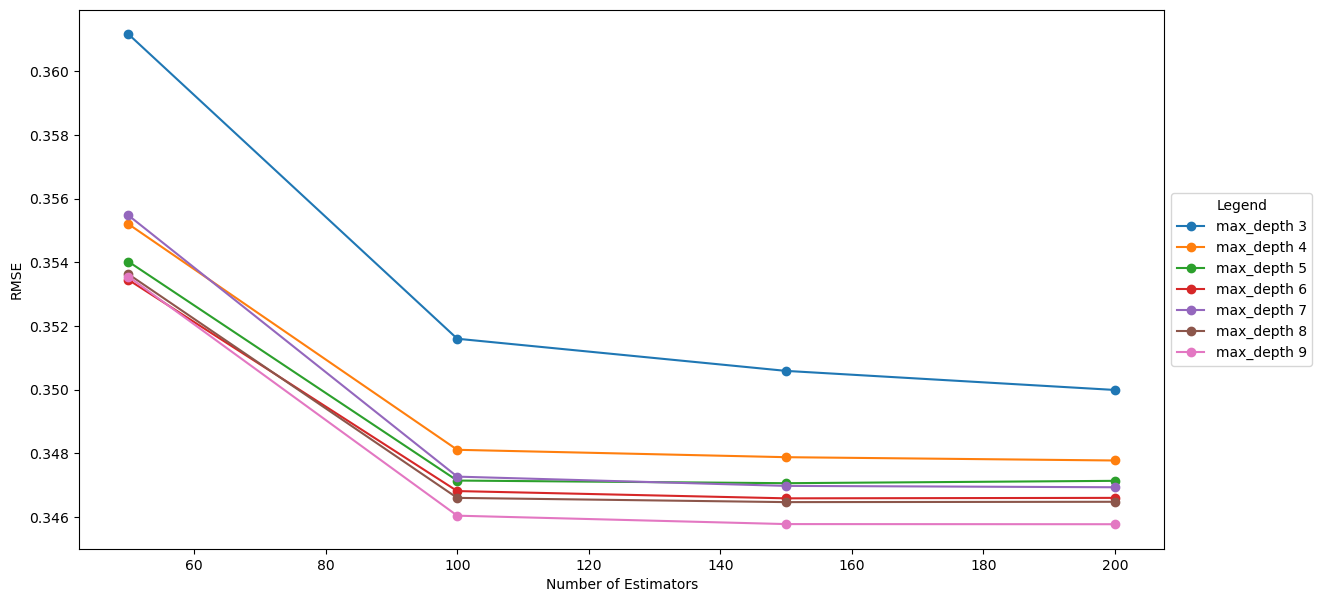

In [54]:
#Extracting the grid search results
results = grid_search.cv_results_

#Extracting mean test scores (convert from negative MSE to RMSE)
mean_test_scores = np.sqrt(-results['mean_test_score'])

#Extracting the grid parameter settings
n_estimators = results['param_n_estimators'].data.astype(int)
max_depth = results['param_max_depth'].data.astype(int)

#Creating a DataFrame to plot
n_est_max_depth = pd.DataFrame({
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'RMSE': mean_test_scores
})

#Plotting
plt.figure(figsize=(14, 7))
for depth in sorted(n_est_max_depth['max_depth'].unique()):
    subset = n_est_max_depth[n_est_max_depth['max_depth'] == depth]
    plt.plot(subset['n_estimators'], subset['RMSE'], marker='o', label=f'max_depth {depth}')

plt.xlabel('Number of Estimators')
plt.ylabel('RMSE')
plt.legend(title='Legend', loc='center left', bbox_to_anchor=(1.0, 0.5))  # positions legend outside figure
plt.show()


In [55]:
#Listing fixed params 
n_estimators = 50, 
max_depth = 6
subsample=0.8,
colsample_bytree=0.8
colsample_bylevel=0.8
gamma=0
objective='reg:squarederror' 

#Defining the parameter grid for n_estimators and max_depth
param_grid = {
    'learning_rate': [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3],
    'min_child_weight': range(5, 21, 1)
}

#Setting up the GridSearchCV object
grid_search_2 = GridSearchCV(estimator=xg_reg, param_grid=param_grid, 
                           scoring='neg_mean_squared_error', cv=tscv, verbose=1)

#Fitting the grid search to the data
grid_search_2.fit(X_train_rest, y_train_rest)

#Printing best parameters and RMSE
print("Best parameters:", grid_search_2.best_params_)
print("Best RMSE:", (-grid_search_2.best_score_)**0.5)

Fitting 5 folds for each of 112 candidates, totalling 560 fits
Best parameters: {'learning_rate': 0.3, 'min_child_weight': 5}
Best RMSE: 0.3891757664869915


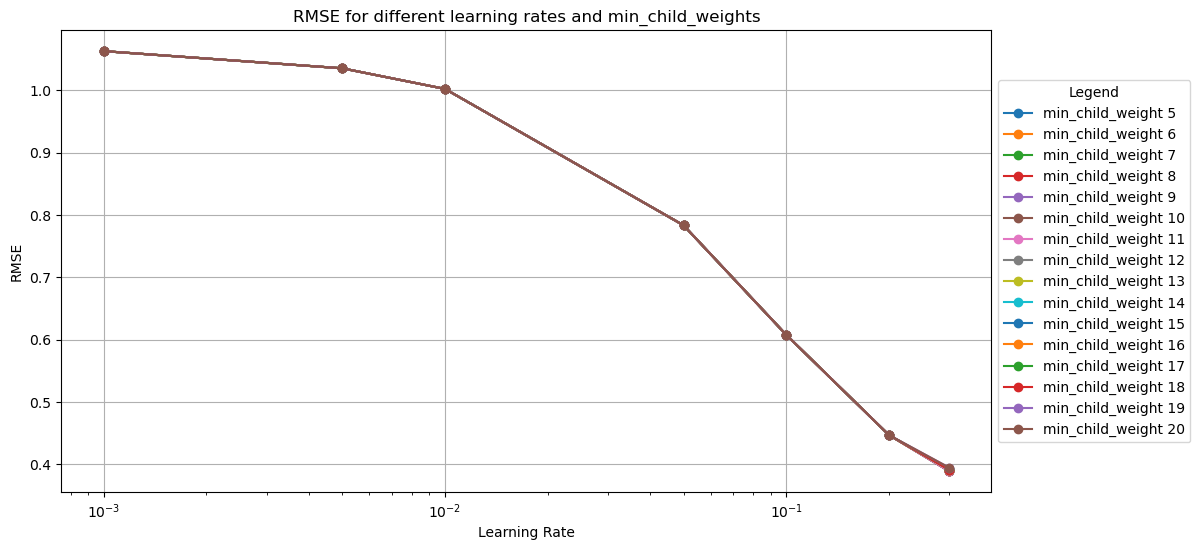

In [56]:
#Extracting the grid search results
results = grid_search_2.cv_results_

#Converting from negative MSE to RMSE
mean_test_scores = np.sqrt(-results['mean_test_score'])

#Extracting parameter settings for each combination
learning_rates = results['param_learning_rate'].data
min_child_weights = results['param_min_child_weight'].data

#Creating a DataFrame for easy plotting
learning_min_child_weight = pd.DataFrame({
    'learning_rate': learning_rates.astype(float),
    'min_child_weight': min_child_weights.astype(int),
    'RMSE': mean_test_scores
})

#Sorting for proper line plotting
learning_min_child_weight.sort_values(['min_child_weight', 'learning_rate'], inplace=True)

#Plotting 
plt.figure(figsize=(12, 6))

for weight in sorted(learning_min_child_weight['min_child_weight'].unique()):
    subset = learning_min_child_weight[learning_min_child_weight['min_child_weight'] == weight]
    plt.plot(subset['learning_rate'], subset['RMSE'], marker='o', label=f'min_child_weight {weight}')

plt.xscale('log')  # setting x-axis to logarithmic scale to accommodate the wide range of learning rates
plt.xlabel('Learning Rate')
plt.ylabel('RMSE')
plt.title('RMSE for different learning rates and min_child_weights')
plt.legend(title='Legend', loc='center left', bbox_to_anchor=(1, 0.5)) 
plt.grid(True)
plt.show()


In [57]:
#Listing fixed params 
n_estimators = 50
learning_rate = 0.2
min_child_weight = 5
max_depth = 6
subsample=0.8
gamma=0
objective='reg:squarederror' 

#Defining the parameter grid for n_estimators and max_depth
param_grid = {
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1],
    'colsample_bylevel': [0.5, 0.6, 0.7, 0.8, 0.9, 1]
}

#Setting up the GridSearchCV object
grid_search_3 = GridSearchCV(estimator=xg_reg, param_grid=param_grid, 
                           scoring='neg_mean_squared_error', cv=tscv, verbose=1)

#Fitting the grid search to the data
grid_search_3.fit(X_train_rest, y_train_rest)

#Printing best parameters and RMSE
print("Best parameters:", grid_search_3.best_params_)
print("Best RMSE:", (-grid_search_3.best_score_)**0.5)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'colsample_bylevel': 0.5, 'colsample_bytree': 0.5}
Best RMSE: 0.6033111511659855


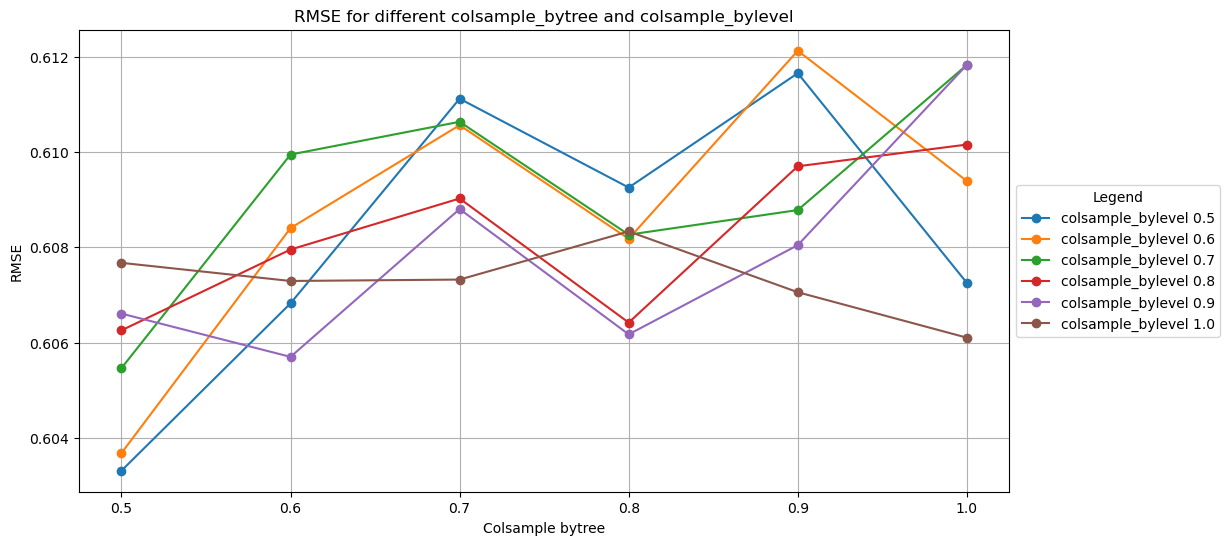

In [58]:
#Repeating the steps above 

results = grid_search_3.cv_results_

mean_test_scores = np.sqrt(-results['mean_test_score'])

colsample_bytree_values = results['param_colsample_bytree'].data
colsample_bylevel_values = results['param_colsample_bylevel'].data

colsample_bytree_bylevel = pd.DataFrame({
    'colsample_bytree': colsample_bytree_values.astype(float),
    'colsample_bylevel': colsample_bylevel_values.astype(float),
    'RMSE': mean_test_scores
})

colsample_bytree_bylevel.sort_values(['colsample_bylevel', 'colsample_bytree'], inplace=True)

plt.figure(figsize=(12, 6))

for level in sorted(colsample_bytree_bylevel['colsample_bylevel'].unique()):
    subset = colsample_bytree_bylevel[colsample_bytree_bylevel['colsample_bylevel'] == level]
    plt.plot(subset['colsample_bytree'], subset['RMSE'], marker='o', label=f'colsample_bylevel {level}')

plt.xlabel('Colsample bytree')
plt.ylabel('RMSE')
plt.title('RMSE for different colsample_bytree and colsample_bylevel')
plt.legend(title='Legend', loc='center left', bbox_to_anchor=(1, 0.5))  
plt.grid(True)
plt.show()


In [59]:
#Listing fixed params 
n_estimators = 50
learning_rate = 0.2
min_child_weight = 5
max_depth = 6
colsample_bylevel = 0.5
colsample_bytree = 1
objective='reg:squarederror' 

param_grid = {
    'subsample': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    'gamma': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
}

grid_search_4 = GridSearchCV(estimator=xg_reg, param_grid=param_grid, 
                           scoring='neg_mean_squared_error', cv=tscv, verbose=1)

grid_search_4.fit(X_train_rest, y_train_rest)

print("Best parameters:", grid_search_4.best_params_)
print("Best RMSE:", (-grid_search_4.best_score_)**0.5)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'gamma': 0.1, 'subsample': 1}
Best RMSE: 0.6076744777348909


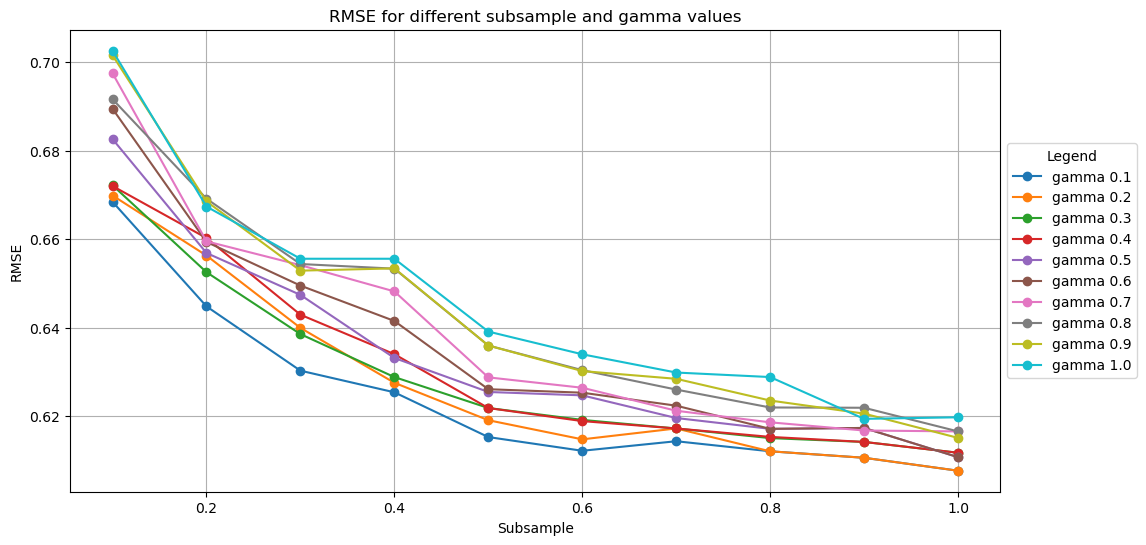

In [60]:
results = grid_search_4.cv_results_

mean_test_scores = np.sqrt(-results['mean_test_score'])

subsample_values = results['param_subsample'].data
gamma_values = results['param_gamma'].data

sub_gamma = pd.DataFrame({
    'subsample': subsample_values.astype(float),
    'gamma': gamma_values.astype(float),
    'RMSE': mean_test_scores
})

# Sorting for proper line plotting
sub_gamma.sort_values(['gamma', 'subsample'], inplace=True)

# Plot settings
plt.figure(figsize=(12, 6))

# Iterate over each unique value of gamma and plot
for gamma in sorted(sub_gamma['gamma'].unique()):
    subset = sub_gamma[sub_gamma['gamma'] == gamma]
    plt.plot(subset['subsample'], subset['RMSE'], marker='o', label=f'gamma {gamma}')

plt.xlabel('Subsample')
plt.ylabel('RMSE')
plt.title('RMSE for different subsample and gamma values')
plt.legend(title='Legend', loc='center left', bbox_to_anchor=(1, 0.5))  
plt.grid(True)
plt.show()

## Tuned XGBoost <a class="anchor" id="xgb-tuned"></a>

In [61]:
#Evaluating the best params model on the test set 

#Defining XGBoost regressor instance with hyperparameters and assigning to new variable
xg_reg_tuned = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, max_depth=9, 
                          colsample_bytree=0.5, learning_rate=0.3, min_child_weight=5,
                          subsample=1, colsample_bylevel = 0.5, gamma=0.1) 


#Fitting the model on the whole training set
xg_reg_tuned.fit(X_train_rest, y_train_rest)

#Predicting values using test data
y_test_best_params_XG_boost_pred = xg_reg_tuned.predict(X_test)

#Evaluating the model on the training data
test_best_params_XGboost_rmse = np.sqrt(mean_squared_error(y_test, y_test_best_params_XG_boost_pred))
print(f"Test RMSE: {test_best_params_XGboost_rmse:.2f}")

Test RMSE: 1.82


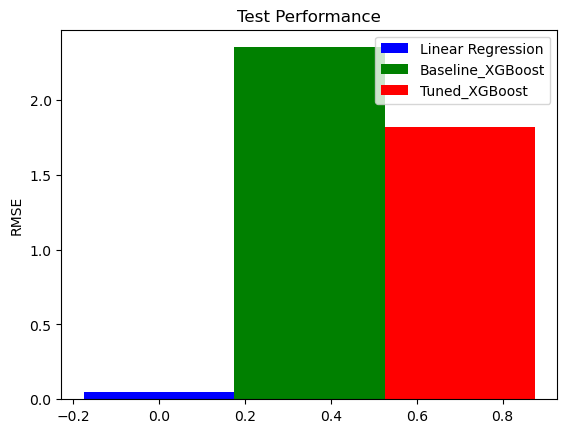

In [62]:
mse_values = {'test': test_lin_reg_rmse}
best_param_xgboost_mse_values = {'test': test_best_params_XGboost_rmse}
baseline_xgboost_mse_values = {'test': test_XGboost_rmse}


labels = list(mse_values.keys())
lin_reg_rmse = list(mse_values.values())
baseline_xgboost_rmse = list(baseline_xgboost_mse_values.values())
best_param_xgboost_rmse = list(best_param_xgboost_mse_values.values())

# Number of groups and bar width
num_groups = len(labels)
bar_width = 0.35

# Create indices for each set of bars
index = np.arange(num_groups)

# Plotting the bars for Linear Regression, baseline and tuned XGBoost
plt.bar(index, lin_reg_rmse, bar_width, label='Linear Regression', color='blue')
plt.bar(index + bar_width, baseline_xgboost_rmse, bar_width, label='Baseline_XGBoost', color='green')
plt.bar(index + bar_width + bar_width, best_param_xgboost_rmse, bar_width, label='Tuned_XGBoost', color='red')




plt.ylabel('RMSE')
plt.title('Test Performance')
plt.legend()
plt.show()

We observe an improvement in the test performance of the XGboost regressor after hyperparameter tuning but compared to the Linear Regression model its performance remains poor. 

### Feature Importance  <a class="anchor" id="xgb-feature-importance"></a>

In [63]:
#Feature importance based on gain
gain_importances = xg_reg_tuned.get_booster().get_score(importance_type='gain')

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

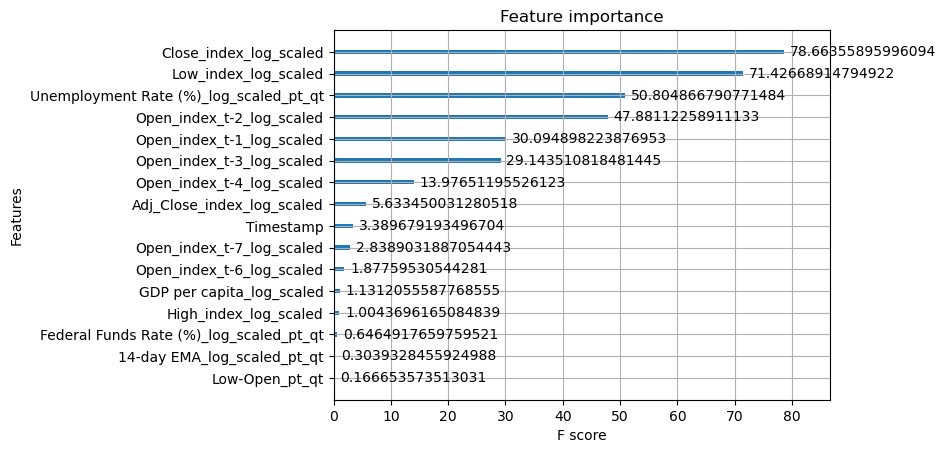

In [64]:
xgb.plot_importance(xg_reg_tuned, importance_type='gain')

We observe that a majority of the features that contribute most to model improvement at every split have reference to the Index Open Price itself.

# Extra Visualisations for Report

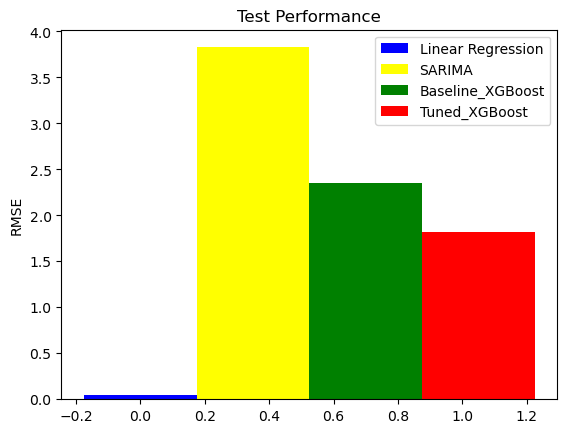

In [65]:
#Creating a comparative chart across classical models for
mse_values = {'test': test_lin_reg_rmse}
sarima_mse_values = {'test': SARIMA_test_rmse}
best_param_xgboost_mse_values = {'test': test_best_params_XGboost_rmse}
baseline_xgboost_mse_values = {'test': test_XGboost_rmse}


labels = list(mse_values.keys())
lin_reg_rmse = list(mse_values.values())
sarima_rmse = list(sarima_mse_values.values())
baseline_xgboost_rmse = list(baseline_xgboost_mse_values.values())
best_param_xgboost_rmse = list(best_param_xgboost_mse_values.values())

#Defining number of labels and bar width
num_groups = len(labels)
bar_width = 0.35

# Create indices for each set of bars
index = np.arange(num_groups)

# Plotting the bars for Linear Regression, baseline and tuned XGBoost
plt.bar(index, lin_reg_rmse, bar_width, label='Linear Regression', color='blue')
plt.bar(index + bar_width, sarima_rmse, bar_width, label='SARIMA', color='yellow')
plt.bar(index + bar_width + bar_width, baseline_xgboost_rmse, bar_width, label='Baseline_XGBoost', color='green')
plt.bar(index + bar_width + bar_width + bar_width, best_param_xgboost_rmse, bar_width, label='Tuned_XGBoost', color='red')



plt.ylabel('RMSE')
plt.title('Test Performance')
plt.legend()
plt.show()